# Barcelona Grand Prix - 2026 🇪🇸 | The Race

- This notebook is full post-race technical debrief of the Barcelona Grandprix - 2026.
- I have tried to work with the data the best I can considering the limitations that I have faced, most significantly not having access to the telemetry of the cars.
- Hence, I have researched technical regulations for hard limits while resonable assumptions where possible to navigate the problems.

## Necessary Imports

In [1]:
# FastF1 Deps
import fastf1

# Data Deps
import pandas as pd

# Visualisation Deps
import matplotlib.pyplot as plt
from plotly.offline import init_notebook_mode

# Core Deps
from pathlib import Path
import sys
sys.path.append(str(Path("../../")))

# Source Deps
from mark_1 import DataLoader, DataPipeline, DataVisualisation
from mark_1.config import CarSepecifications, RaceStrategyConfig

# Plotly Notebook Orchestration
init_notebook_mode(connected=True)

## Notebook-Level Setup and Configurations

In [2]:
# Accessing the Current Working Directory for Absolute Root Path
REPO_ROOT_PATH = Path.cwd().parent.parent.parent

# Pathlib Path Objects for the Notebook
F1_PATH = REPO_ROOT_PATH / "F1"
F1_DATA_PATH = F1_PATH / "data"
CACHE_PATH = F1_PATH / "cache"
CACHE_PATH.mkdir(exist_ok=True)

# Adding the source scripts into the Python Execution Path
if F1_PATH not in sys.path:
    sys.path.append(str(F1_PATH))

## Loading the Event

In [3]:
# Defaulting the Requests for Caching to a Predefined path
# fastf1.Cache.clear_cache(cache_dir=str(CACHE_PATH))
fastf1.Cache.enable_cache(cache_dir=str(CACHE_PATH))

# Enabling Offline Mode
fastf1.Cache.offline_mode(enabled=True)

# The GP Event
barcelona_2026 = fastf1.get_event(
    year=2026,
    gp="barcelona"
)
print(barcelona_2026)

RoundNumber                                                          7
Country                                                          Spain
Location                                                     Barcelona
OfficialEventName    FORMULA 1 MSC CRUISES GRAN PREMIO DE BARCELONA...
EventDate                                          2026-06-14 00:00:00
EventName                                         Barcelona Grand Prix
EventFormat                                               conventional
Session1                                                    Practice 1
Session1Date                                 2026-06-12 13:30:00+02:00
Session1DateUtc                                    2026-06-12 11:30:00
Session2                                                    Practice 2
Session2Date                                 2026-06-12 17:00:00+02:00
Session2DateUtc                                    2026-06-12 15:00:00
Session3                                                    Practice 3
Sessio

In [4]:
barcelona_2026 = DataLoader(race_event=barcelona_2026)
gp_weekend = barcelona_2026.load_data()

core           INFO 	Loading data for Barcelona Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '44', '12', '1', '3', '6', '81', '30', '27', '16', '41', '5', '43', '10', '87', '55', '31', '23', '11', '77', '18', '14']
core           INFO 	Loading data for Barcelona Grand Prix - Race [v3.8.3]
req            INFO 

In [5]:
# Decompiling the Data
race = gp_weekend.race_session

In [6]:
# Loading the Performance data from Quali
quali_performance = pd.read_csv(F1_DATA_PATH / "quali_performance_barcelona.csv")
quali_performance

,Driver,Sector1Time,Sector2Time,Sector3Time,LapTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,FrontAEI,BalancedAEI,RearAEI,KineticEnergyS1_KJ,KineticEnergyS2_KJ,KineticEnergyS3_KJ,PowerS1_KW,PowerS2_KW,PowerS3_KW,ERS_Clipping,AccelerationTime
0,HAM,21.873,30.008,22.849,74.743,268.0,294.0,295.0,333.0,0.223097,0.245245,0.244636,1163.510031,728.306944,710.764198,53.193893,24.270426,31.107016,1.128814,5.044586
1,NOR,21.928,30.237,22.772,75.001,274.0,292.0,292.0,333.0,0.227520,0.241732,0.242967,1066.652623,763.213735,763.213735,48.643407,25.241053,33.515446,1.140411,5.068800
2,RUS,21.849,30.115,22.715,74.679,274.0,281.0,298.0,332.0,0.229030,0.234272,0.249331,1046.846296,931.135648,637.972222,47.912778,30.919331,28.085944,1.114094,5.028571
3,VER,21.828,30.184,22.875,75.021,280.0,291.0,294.0,333.0,0.233567,0.241327,0.243530,967.650772,780.577778,728.306944,44.330712,25.860647,31.838555,1.132653,5.052632


## Data Engineering

<img src="../../../assets/circuit_maps/barcelona_map.avif">

In [7]:
# Instantiating the Data Pipeline
data_pipe = DataPipeline(circuit="barcelona")

# Full Laps Frame
assert race, "Race was not loaded"
race_laps_full = race.laps

# Total no of laps in the race
max_laps = race.laps["LapNumber"].max()

# Drop columns
drop_cols = [
    "Sector1SessionTime", "Sector2SessionTime", "Sector3SessionTime", 
    "DeletedReason", "FastF1Generated", "IsAccurate",
    "LapStartDate", "LapStartTime"
]

# Filtered Laps
filtered_race_laps = race_laps_full.drop(drop_cols, axis=1)

# Calculating the Driver Deltas
filtered_race_laps = data_pipe.get_traffic_delta(laps_frame=filtered_race_laps)

# Rounding down to the top runners
top_4_drivers = race.results.iloc[:4]["Abbreviation"]
filtered_race_laps = filtered_race_laps.pick_drivers(top_4_drivers.to_list())
filtered_race_laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,TrackStatus,Position,Deleted,TrafficDelta
0,0 days 00:55:08.537000,NOR,1,0 days 00:01:27.198000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:33.656000,...,293.0,False,MEDIUM,1.0,True,McLaren,1,4.0,False,0.701
1,0 days 00:56:30.788000,NOR,1,0 days 00:01:22.251000,2.0,1.0,NaT,NaT,0 days 00:00:23.744000,0 days 00:00:33.611000,...,335.0,True,MEDIUM,2.0,True,McLaren,1,4.0,False,0.910
2,0 days 00:57:53.210000,NOR,1,0 days 00:01:22.422000,3.0,1.0,NaT,NaT,0 days 00:00:23.976000,0 days 00:00:33.500000,...,340.0,False,MEDIUM,3.0,True,McLaren,1,4.0,False,1.212
3,0 days 00:59:15.983000,NOR,1,0 days 00:01:22.773000,4.0,1.0,NaT,NaT,0 days 00:00:23.999000,0 days 00:00:33.552000,...,334.0,False,MEDIUM,4.0,True,McLaren,1,4.0,False,1.714
4,0 days 01:00:39.270000,NOR,1,0 days 00:01:23.287000,5.0,1.0,NaT,NaT,0 days 00:00:24.189000,0 days 00:00:33.813000,...,332.0,False,MEDIUM,5.0,True,McLaren,1,4.0,False,2.553


In [8]:
# Transforming all the timedelta objects
get_seconds = pd.Timedelta.total_seconds

filtered_race_laps["LapTime"] = filtered_race_laps.apply(
    lambda x: get_seconds(x["LapTime"]),
    axis=1
)
filtered_race_laps["Sector1Time"] = filtered_race_laps.apply(
    lambda x: get_seconds(x["Sector1Time"]),
    axis=1
)
filtered_race_laps["Sector2Time"] = filtered_race_laps.apply(
    lambda x: get_seconds(x["Sector2Time"]),
    axis=1
)
filtered_race_laps["Sector3Time"] = filtered_race_laps.apply(
    lambda x: get_seconds(x["Sector3Time"]),
    axis=1
)

# Picking all the green flag laps without boxing
filtered_race_laps_wo = (
    filtered_race_laps
    .pick_wo_box()
    .pick_track_status(status="1")
    .copy()
)
filtered_race_laps_wo.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,TrackStatus,Position,Deleted,TrafficDelta
0,0 days 00:55:08.537000,NOR,1,87.198,1.0,1.0,NaT,NaT,NaN,33.656,...,293.0,False,MEDIUM,1.0,True,McLaren,1,4.0,False,0.701
1,0 days 00:56:30.788000,NOR,1,82.251,2.0,1.0,NaT,NaT,23.744,33.611,...,335.0,True,MEDIUM,2.0,True,McLaren,1,4.0,False,0.910
2,0 days 00:57:53.210000,NOR,1,82.422,3.0,1.0,NaT,NaT,23.976,33.500,...,340.0,False,MEDIUM,3.0,True,McLaren,1,4.0,False,1.212
3,0 days 00:59:15.983000,NOR,1,82.773,4.0,1.0,NaT,NaT,23.999,33.552,...,334.0,False,MEDIUM,4.0,True,McLaren,1,4.0,False,1.714
4,0 days 01:00:39.270000,NOR,1,83.287,5.0,1.0,NaT,NaT,24.189,33.813,...,332.0,False,MEDIUM,5.0,True,McLaren,1,4.0,False,2.553


### Engineering the Aero Features

In [9]:
# Sector - 1: Front Axle Load
filtered_race_laps_wo.loc[:, "FrontAEI"] = data_pipe.get_aero_efficiency(
    sector="Sector1",
    laps_frame=filtered_race_laps_wo,
    drivers=top_4_drivers.to_list()
)

# Sector - 2: Balanced Load
filtered_race_laps_wo.loc[:, "BalancedAEI"] = data_pipe.get_aero_efficiency(
    sector="Sector2",
    laps_frame=filtered_race_laps_wo,
    drivers=top_4_drivers.to_list()
)

# Sector - 3: Rear Axle Load
filtered_race_laps_wo.loc[:, "RearAEI"] = data_pipe.get_aero_efficiency(
    sector="Sector3",
    laps_frame=filtered_race_laps_wo,
    drivers=top_4_drivers.to_list()
)

filtered_race_laps_wo.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,TyreLife,FreshTyre,Team,TrackStatus,Position,Deleted,TrafficDelta,FrontAEI,BalancedAEI,RearAEI
0,0 days 00:55:08.537000,NOR,1,87.198,1.0,1.0,NaT,NaT,NaN,33.656,...,1.0,True,McLaren,1,4.0,False,0.701,NaN,0.228580,0.274874
1,0 days 00:56:30.788000,NOR,1,82.251,2.0,1.0,NaT,NaT,23.744,33.611,...,2.0,True,McLaren,1,4.0,False,0.910,0.196628,0.195423,0.238785
2,0 days 00:57:53.210000,NOR,1,82.422,3.0,1.0,NaT,NaT,23.976,33.500,...,3.0,True,McLaren,1,4.0,False,1.212,0.195046,0.206537,0.232422
3,0 days 00:59:15.983000,NOR,1,82.773,4.0,1.0,NaT,NaT,23.999,33.552,...,4.0,True,McLaren,1,4.0,False,1.714,0.195930,0.201142,0.234008
4,0 days 01:00:39.270000,NOR,1,83.287,5.0,1.0,NaT,NaT,24.189,33.813,...,5.0,True,McLaren,1,4.0,False,2.553,0.197987,0.202385,0.234030


### Engineering the Kinetic Energy Features

In [10]:
# Sector - 1
filtered_race_laps_wo.loc[:, "KineticEnergyS1_KJ"] = data_pipe.get_delta_kinetic_energy(
    sector="Sector1",
    laps_frame=filtered_race_laps_wo,
    drivers=top_4_drivers.to_list()
)

# Sector - 2
filtered_race_laps_wo.loc[:, "KineticEnergyS2_KJ"] = data_pipe.get_delta_kinetic_energy(
    sector="Sector2",
    laps_frame=filtered_race_laps_wo,
    drivers=top_4_drivers.to_list()
)

# Sector - 3
filtered_race_laps_wo.loc[:, "KineticEnergyS3_KJ"] = data_pipe.get_delta_kinetic_energy(
    sector="Sector3",
    laps_frame=filtered_race_laps_wo,
    drivers=top_4_drivers.to_list()
)

filtered_race_laps_wo.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,TrackStatus,Position,Deleted,TrafficDelta,FrontAEI,BalancedAEI,RearAEI,KineticEnergyS1_KJ,KineticEnergyS2_KJ,KineticEnergyS3_KJ
0,0 days 00:55:08.537000,NOR,1,87.198,1.0,1.0,NaT,NaT,NaN,33.656,...,1,4.0,False,0.701,NaN,0.228580,0.274874,883.987654,665.522377,-70.290123
1,0 days 00:56:30.788000,NOR,1,82.251,2.0,1.0,NaT,NaT,23.744,33.611,...,1,4.0,False,0.910,0.196628,0.195423,0.238785,1612.622222,1540.098302,732.953241
2,0 days 00:57:53.210000,NOR,1,82.422,3.0,1.0,NaT,NaT,23.976,33.500,...,1,4.0,False,1.212,0.195046,0.206537,0.232422,1655.243056,1382.898611,886.102315
3,0 days 00:59:15.983000,NOR,1,82.773,4.0,1.0,NaT,NaT,23.999,33.552,...,1,4.0,False,1.714,0.195930,0.201142,0.234008,1578.311111,1431.178395,765.656019
4,0 days 01:00:39.270000,NOR,1,83.287,5.0,1.0,NaT,NaT,24.189,33.813,...,1,4.0,False,2.553,0.197987,0.202385,0.234030,1495.124537,1361.364815,743.407407


### Engineering the Power Features

In [11]:
# Sector - 1
filtered_race_laps_wo.loc[:, "PowerS1_KW"] = data_pipe.get_power_expenditure(
    sector="Sector1",
    laps_frame=filtered_race_laps_wo,
    drivers=top_4_drivers.to_list()
)

# Sector - 2
filtered_race_laps_wo.loc[:, "PowerS2_KW"] = data_pipe.get_power_expenditure(
    sector="Sector2",
    laps_frame=filtered_race_laps_wo,
    drivers=top_4_drivers.to_list()
)

# Sector - 3
filtered_race_laps_wo.loc[:, "PowerS3_KW"] = data_pipe.get_power_expenditure(
    sector="Sector3",
    laps_frame=filtered_race_laps_wo,
    drivers=top_4_drivers.to_list()
)

filtered_race_laps_wo.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,TrafficDelta,FrontAEI,BalancedAEI,RearAEI,KineticEnergyS1_KJ,KineticEnergyS2_KJ,KineticEnergyS3_KJ,PowerS1_KW,PowerS2_KW,PowerS3_KW
0,0 days 00:55:08.537000,NOR,1,87.198,1.0,1.0,NaT,NaT,NaN,33.656,...,0.701,NaN,0.228580,0.274874,883.987654,665.522377,-70.290123,NaN,19.774256,-2.833023
1,0 days 00:56:30.788000,NOR,1,82.251,2.0,1.0,NaT,NaT,23.744,33.611,...,0.910,0.196628,0.195423,0.238785,1612.622222,1540.098302,732.953241,67.917041,45.821258,29.440603
2,0 days 00:57:53.210000,NOR,1,82.422,3.0,1.0,NaT,NaT,23.976,33.500,...,1.212,0.195046,0.206537,0.232422,1655.243056,1382.898611,886.102315,69.037498,41.280556,35.520818
3,0 days 00:59:15.983000,NOR,1,82.773,4.0,1.0,NaT,NaT,23.999,33.552,...,1.714,0.195930,0.201142,0.234008,1578.311111,1431.178395,765.656019,65.765703,42.655532,30.356673
4,0 days 01:00:39.270000,NOR,1,83.287,5.0,1.0,NaT,NaT,24.189,33.813,...,2.553,0.197987,0.202385,0.234030,1495.124537,1361.364815,743.407407,61.810101,40.261580,29.401123


### Engineering the Fuel and Pace Features

In [12]:
# Instances of all the configs
car_spec = CarSepecifications()
race_spec = RaceStrategyConfig()

In [13]:
# Engineering all the pace features using the pipeline
driver_fuel_flow = {}

mean_race_laps = data_pipe.get_mean_race_laps(
    laps_frame=filtered_race_laps_wo,
    drivers=top_4_drivers.to_list()
)

effective_fuel_load = data_pipe.get_effective_fuel_load(
    max_fuel_load_in_kg=car_spec.MAX_FUEL_LOAD_IN_KG,
    fuel_sample_limit=race_spec.FUEL_SAMPLE_LIMIT,
    fuel_strat=race_spec.FUEL_STRAT
)

for _, row in mean_race_laps.iterrows():
    fuel_flow = data_pipe.get_effective_fuel_flow(
        effective_fuel_load=effective_fuel_load,
        avg_laptime=row["LapTime"],
        race_laps=max_laps
    )
    driver_fuel_flow[row["Driver"]] = fuel_flow

driver_fuel_flow

{'HAM': np.float64(11.496260563116511),
 'NOR': np.float64(11.407668794307293),
 'RUS': np.float64(11.414138066886851),
 'VER': np.float64(11.41085385695191)}

In [14]:
# LapFuelBurn: Fuel burnt over a single lap based on laptime
filtered_race_laps_wo.loc[:, "LapFuelBurn"] = filtered_race_laps_wo.apply(
    lambda x: data_pipe.get_lap_fuel_burn(
        laptime=x["LapTime"],
        effective_fuel_flow=driver_fuel_flow[x["Driver"]]
    ), 
    axis=1
)

# CumulativeFuelBurn: The fuel burnt over the race distance based on laptimes
filtered_race_laps_wo.loc[:, "CumulativeFuelBurn"] = (
    filtered_race_laps_wo
    .groupby("Driver")["LapFuelBurn"]
    .cumsum()
)

# LapFuelPenality: Zero-Fuel Pace for each race lap based on the cumulative fuel burn offset
filtered_race_laps_wo.loc[:, "LapFuelPenality"] = filtered_race_laps_wo.apply(
    lambda x: data_pipe.get_lap_fuel_penality(
        cumulative_fuel_burn=x["CumulativeFuelBurn"],
        effective_fuel_load=effective_fuel_load
    ),
    axis=1
)

# FuelAwareLapTime: Final Zero-Fuel laptime within the assumed parameters
filtered_race_laps_wo["FuelAwareLapTime"] = filtered_race_laps_wo.apply(
    lambda x: data_pipe.get_fuel_aware_laptime(
        laptime=x["LapTime"], 
        fuel_penality=x["LapFuelPenality"]
    ),
    axis=1
)
filtered_race_laps_wo.tail()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,KineticEnergyS1_KJ,KineticEnergyS2_KJ,KineticEnergyS3_KJ,PowerS1_KW,PowerS2_KW,PowerS3_KW,LapFuelBurn,CumulativeFuelBurn,LapFuelPenality,FuelAwareLapTime
1086,0 days 02:14:32.704000,RUS,63,81.946,58.0,3.0,NaT,NaT,23.776,33.259,...,1238.416667,1191.328241,637.972222,52.086838,35.819725,25.610061,0.935343,47.884695,0.423459,81.522541
1087,0 days 02:15:54.975000,RUS,63,82.271,59.0,3.0,NaT,NaT,23.878,33.394,...,1238.416667,1222.780093,637.972222,51.864338,36.616760,25.519910,0.939053,48.823747,0.395288,81.875712
1088,0 days 02:17:17.161000,RUS,63,82.186,60.0,3.0,NaT,NaT,23.834,33.339,...,1207.083951,1207.083951,637.972222,50.645462,36.206363,25.505626,0.938082,49.761830,0.367145,81.818855
1089,0 days 02:18:41.723000,RUS,63,84.562,61.0,3.0,NaT,NaT,24.839,34.343,...,1480.500617,1284.968981,637.972222,59.603874,37.415746,25.136809,0.965202,50.727032,0.338189,84.223811
1094,0 days 02:26:29.005000,RUS,63,82.322,66.0,3.0,NaT,NaT,23.860,33.312,...,1260.933333,1151.894290,616.259722,52.847164,34.578959,24.503369,0.939635,51.666667,0.310000,82.012000


In [15]:
max_fuel_burns = filtered_race_laps_wo.groupby("Driver")["CumulativeFuelBurn"].last().reset_index()

# Sanity Check for Fuel Load
print(f"Effective Fuel Load: {effective_fuel_load}")

print("\nDriver | Max Fuel Burn")
for _, row in max_fuel_burns.iterrows():
    print(row["Driver"], " | ", row["CumulativeFuelBurn"])

Effective Fuel Load: 62

Driver | Max Fuel Burn
HAM  |  52.60606060606061
NOR  |  51.666666666666664
RUS  |  51.66666666666668
VER  |  53.54545454545455


## Data Visualisation

In [16]:
# Instantiating the Data Visualisation Handle
assert race, "The race session wasn't loaded"

data_vis = DataVisualisation(
    session=race,
    driver_names=top_4_drivers.to_list(),
    circuit="barcelona"
)

req            INFO 	Using cached data for driver_info


### Simple Tyre Degradation Plots

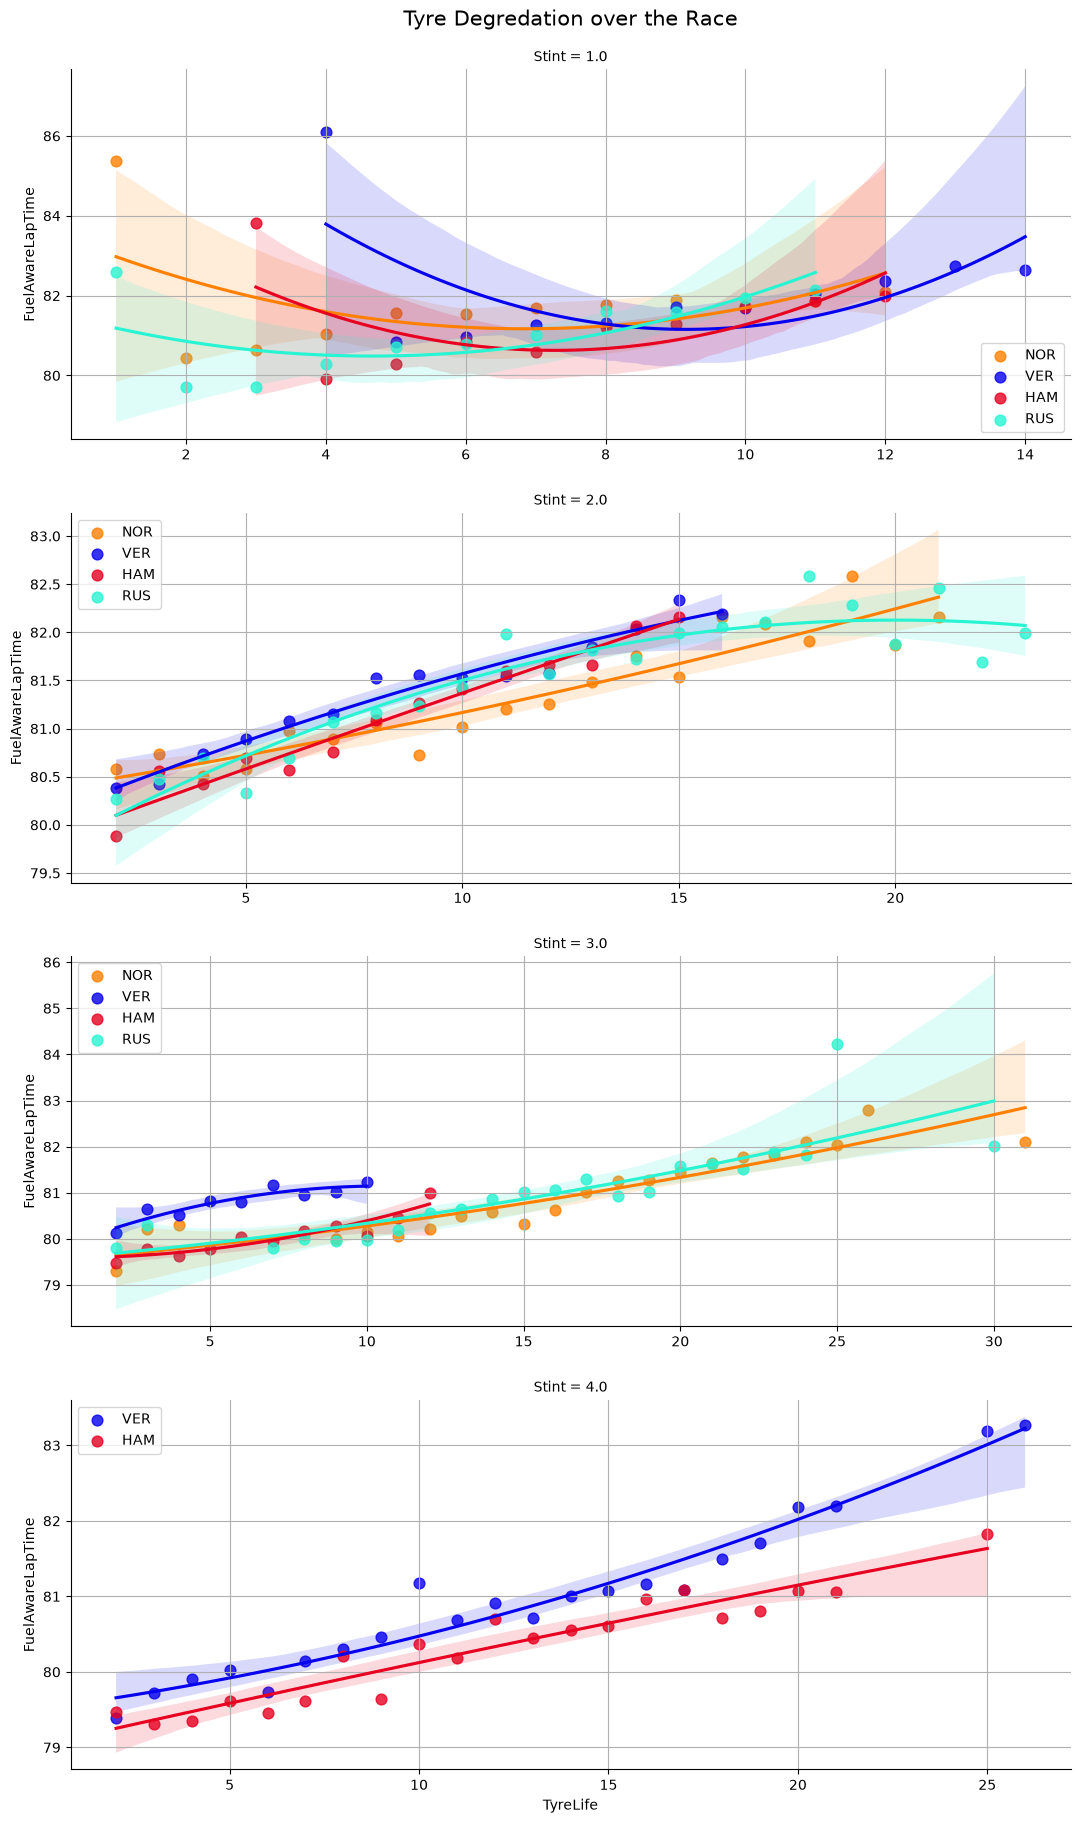

In [17]:
pace_deg_grid = data_vis.create_degradation_plot(
    laps_frame=filtered_race_laps_wo,
    x="TyreLife",
    y="FuelAwareLapTime",
    order=2,
    hue="Driver",
    height=5,
    aspect=2.5,
    row="Stint"
)

pace_deg_grid.figure.suptitle(
    "Tyre Degredation over the Race",
    fontsize=15
)
plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.95, hspace=0.2)
plt.show()

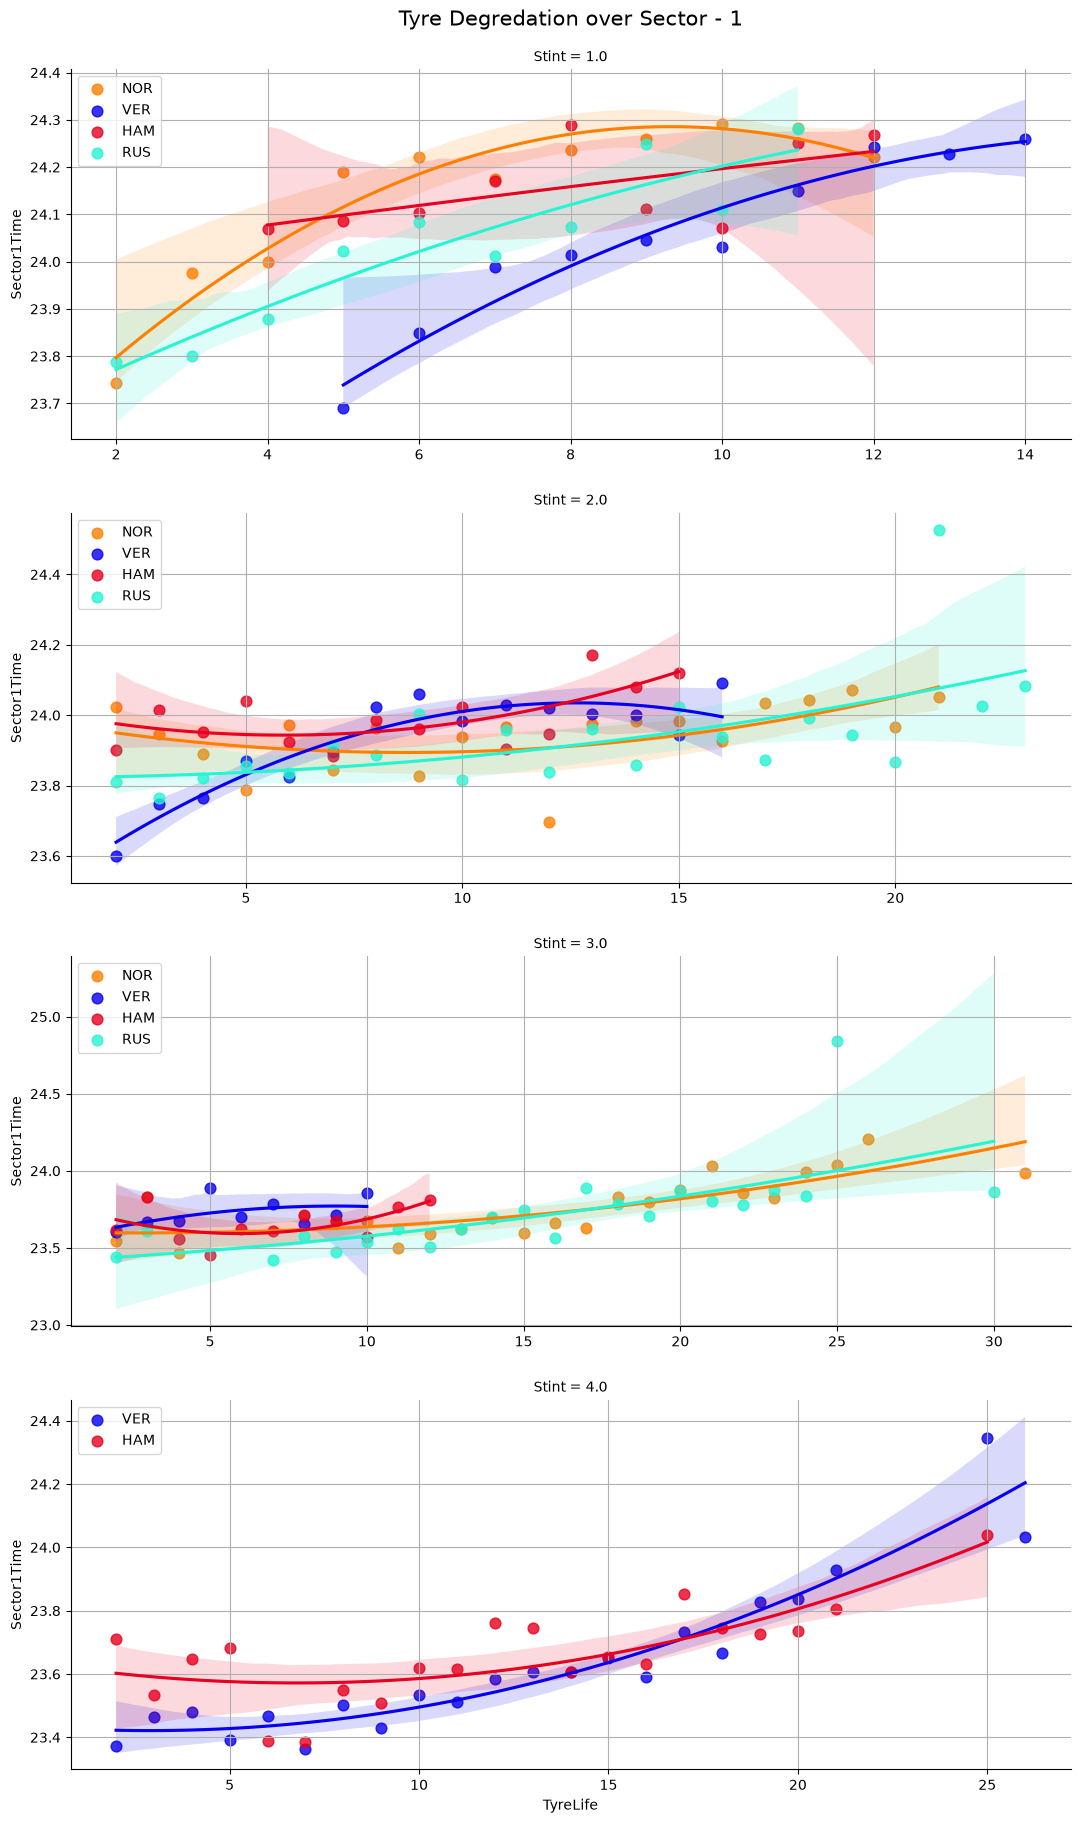

In [18]:
sector1_deg_grid = data_vis.create_degradation_plot(
    laps_frame=filtered_race_laps_wo,
    x="TyreLife",
    y="Sector1Time",
    order=2,
    hue="Driver",
    height=5,
    aspect=2.5,
    row="Stint"
)

sector1_deg_grid.figure.suptitle(
    "Tyre Degredation over Sector - 1",
    fontsize=15
)
plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.95, hspace=0.2)
plt.show()

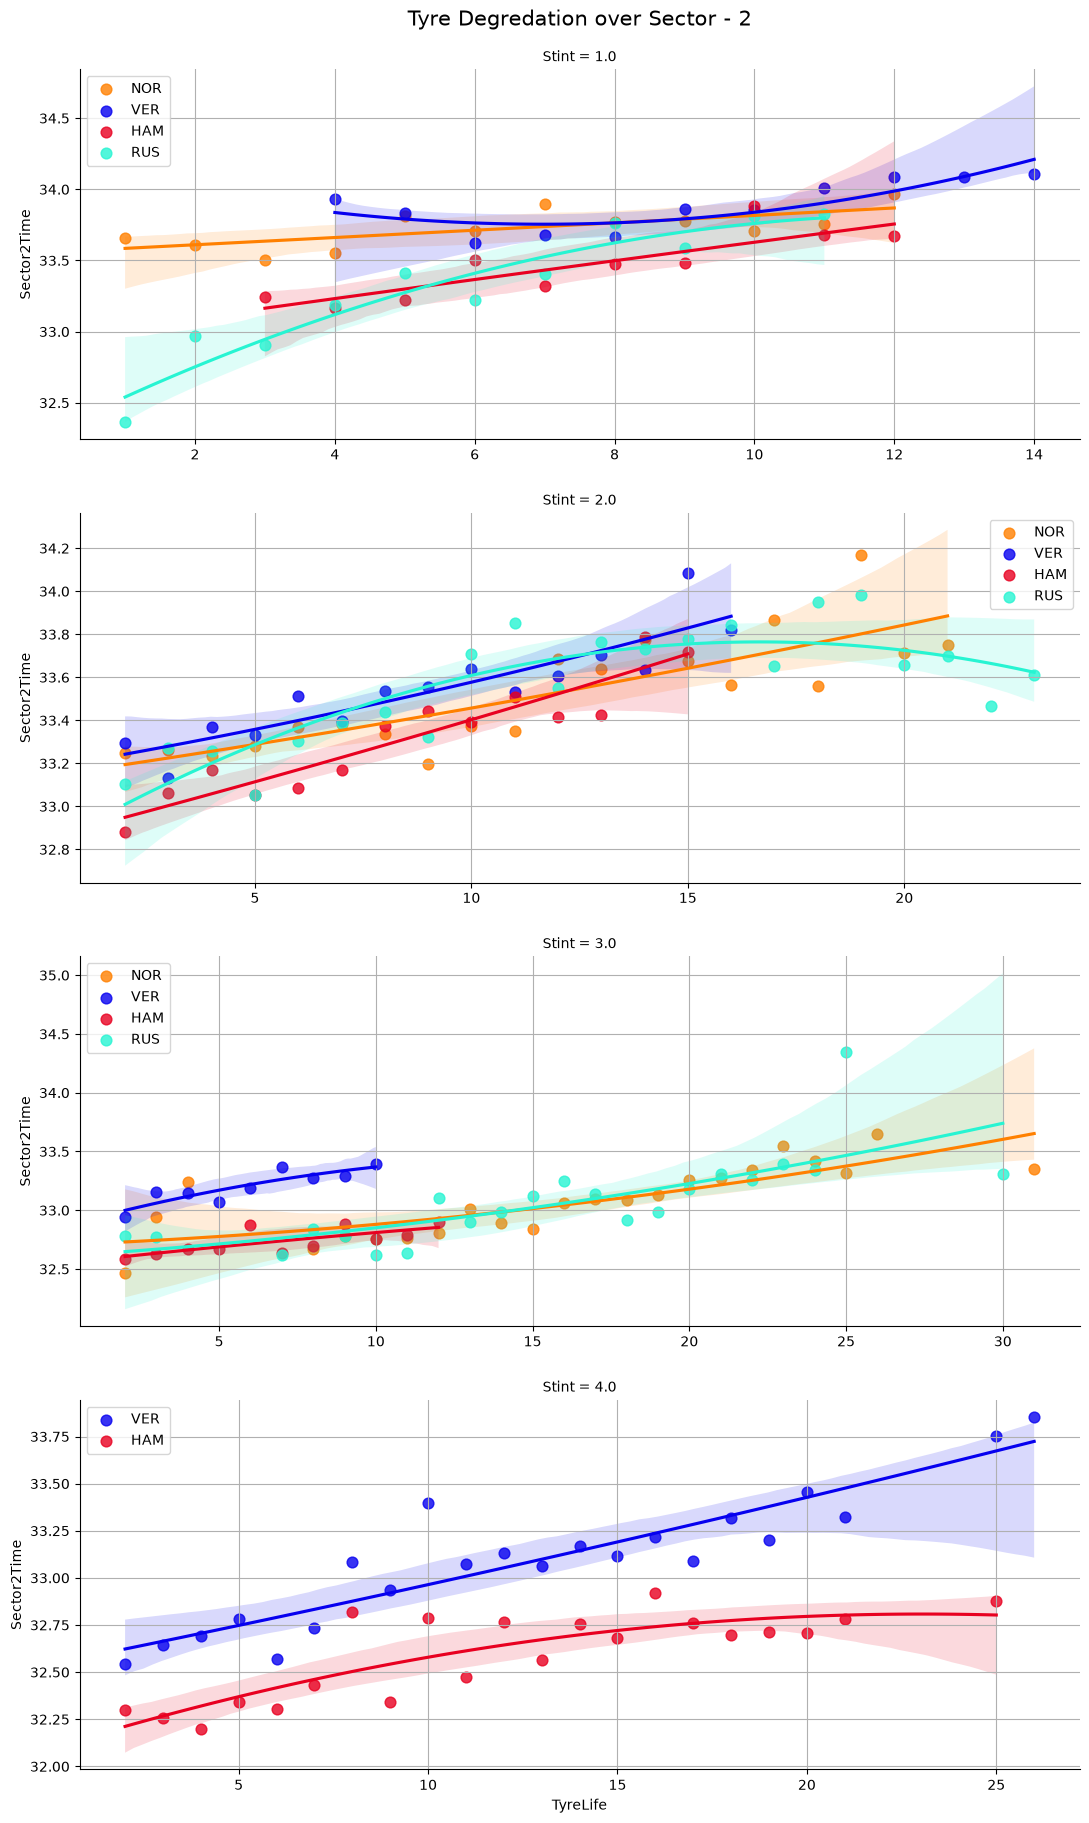

In [19]:
sector2_deg_grid = data_vis.create_degradation_plot(
    laps_frame=filtered_race_laps_wo,
    x="TyreLife",
    y="Sector2Time",
    order=2,
    hue="Driver",
    height=5,
    aspect=2.5,
    row="Stint"
)

sector2_deg_grid.figure.suptitle(
    "Tyre Degredation over Sector - 2",
    fontsize=15
)
plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.95, hspace=0.2)
plt.show()

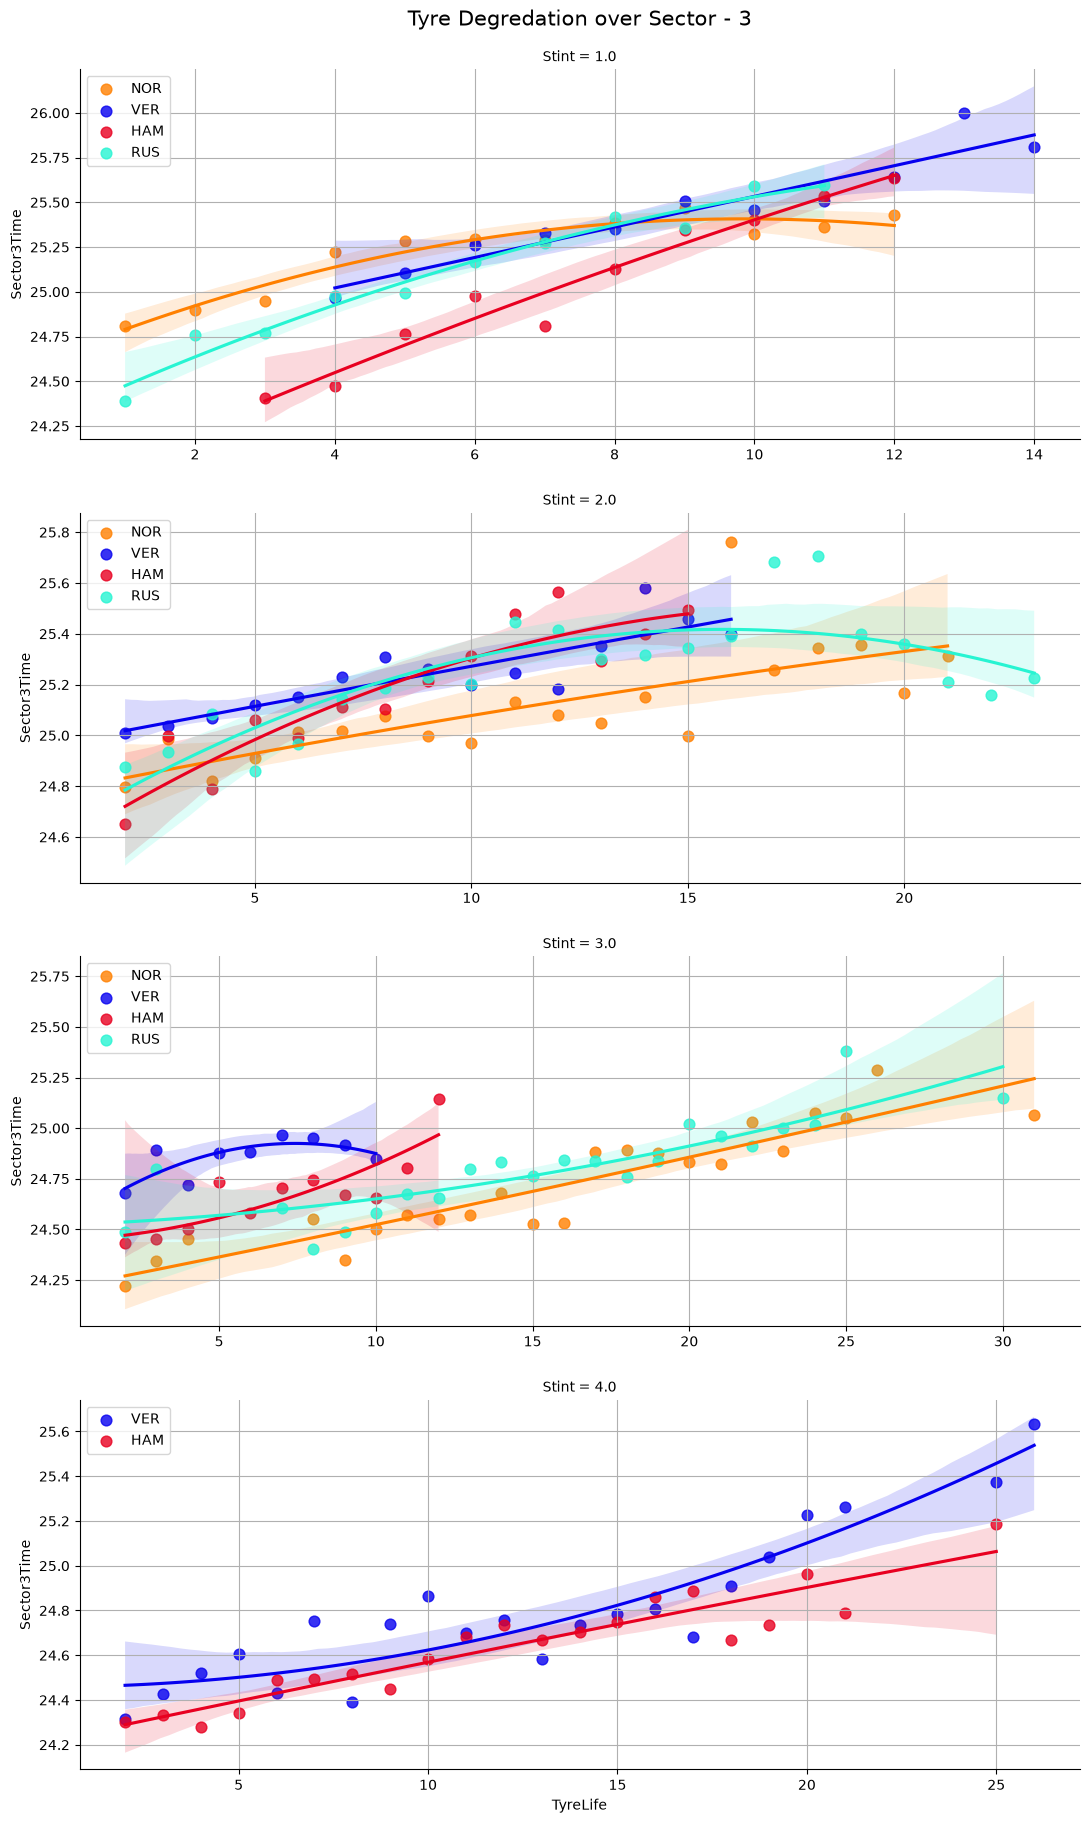

In [20]:
sector3_deg_grid = data_vis.create_degradation_plot(
    laps_frame=filtered_race_laps_wo,
    x="TyreLife",
    y="Sector3Time",
    order=2,
    hue="Driver",
    height=5,
    aspect=2.5,
    row="Stint"
)

sector3_deg_grid.figure.suptitle(
    "Tyre Degredation over Sector - 3",
    fontsize=15
)
plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.95, hspace=0.2)
plt.show()

### Raw Pace Plots

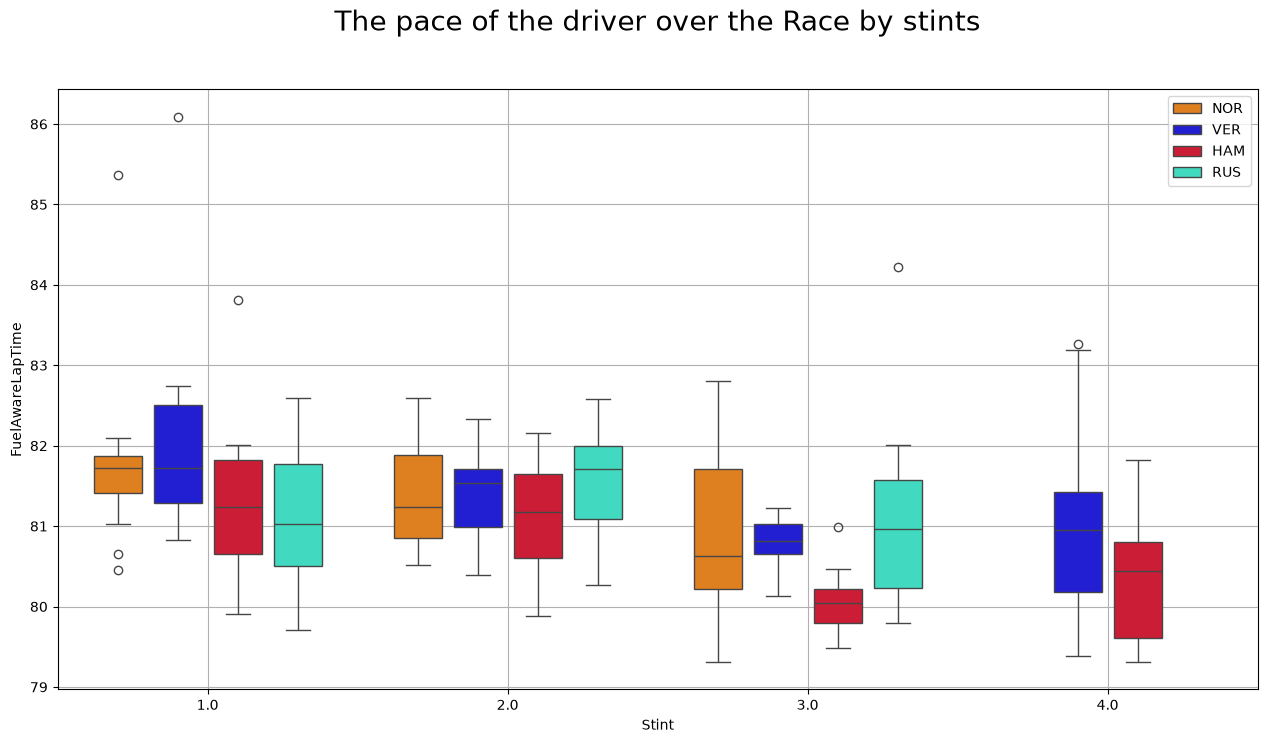

In [21]:
pace_grid = data_vis.create_pace_plot(
    laps_frame=filtered_race_laps_wo,
    x="Stint",
    y="FuelAwareLapTime",
    hue="Driver",
    figsize=(30, 10)
)

pace_grid.figure.suptitle(
    t="The pace of the driver over the Race by stints",
    fontsize=20
)
plt.subplots_adjust(left=0.3, right=0.7, top=0.9, bottom=0.3)
plt.show()

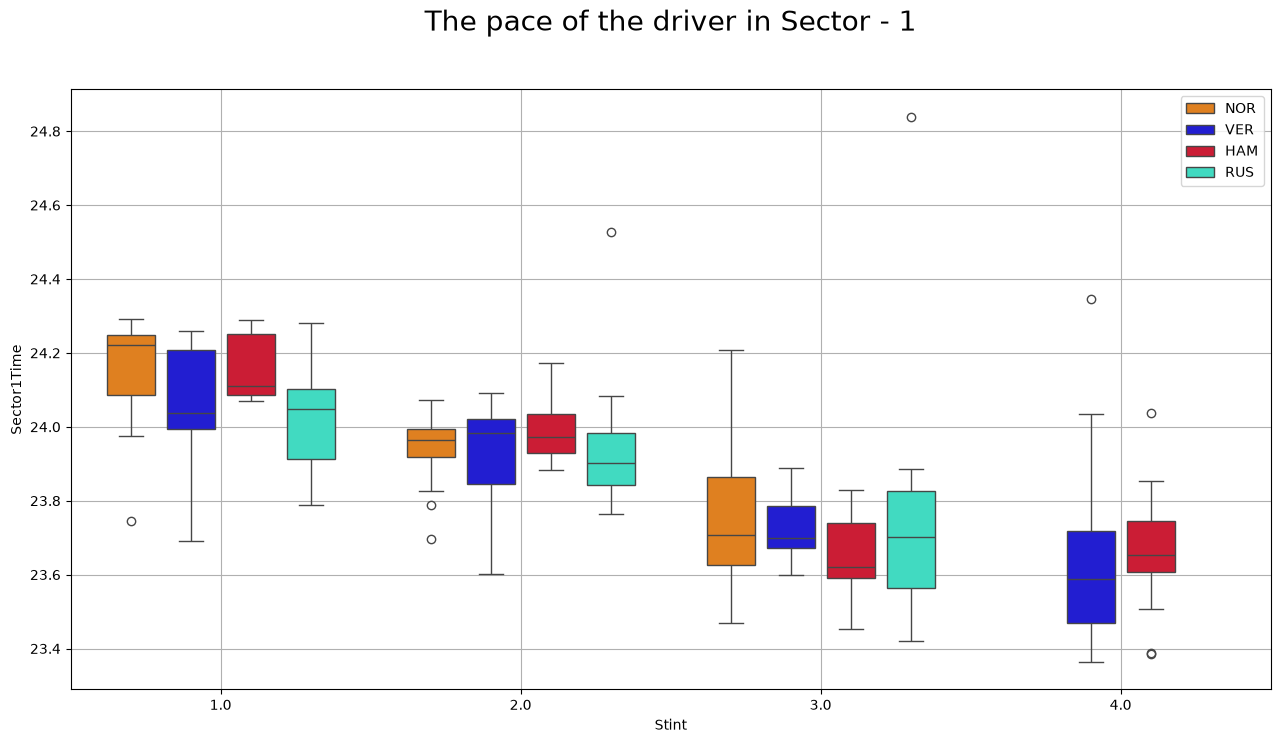

In [22]:
pace_grid = data_vis.create_pace_plot(
    laps_frame=filtered_race_laps_wo,
    x="Stint",
    y="Sector1Time",
    hue="Driver",
    figsize=(30, 10)
)

pace_grid.figure.suptitle(
    t="The pace of the driver in Sector - 1",
    fontsize=20
)
plt.subplots_adjust(left=0.3, right=0.7, top=0.9, bottom=0.3)
plt.show()

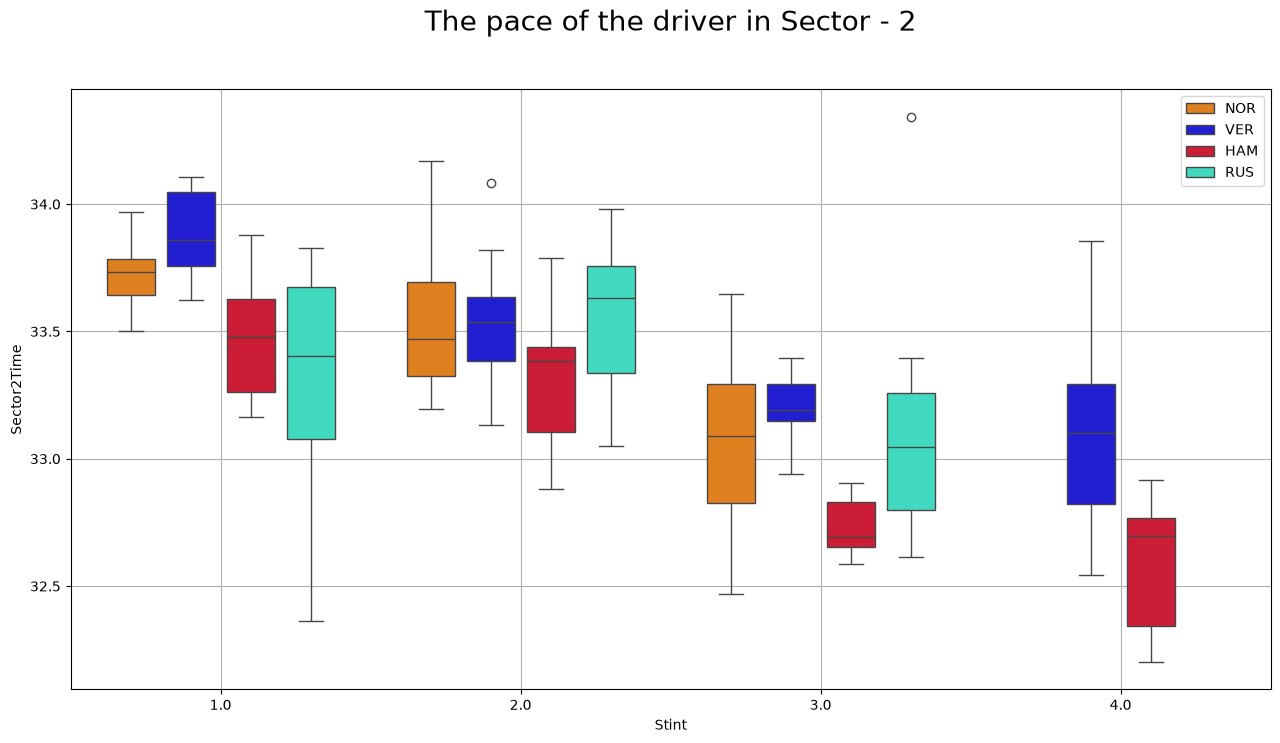

In [23]:
pace_grid = data_vis.create_pace_plot(
    laps_frame=filtered_race_laps_wo,
    x="Stint",
    y="Sector2Time",
    hue="Driver",
    figsize=(30, 10)
)

pace_grid.figure.suptitle(
    t="The pace of the driver in Sector - 2",
    fontsize=20
)
plt.subplots_adjust(left=0.3, right=0.7, top=0.9, bottom=0.3)
plt.show()

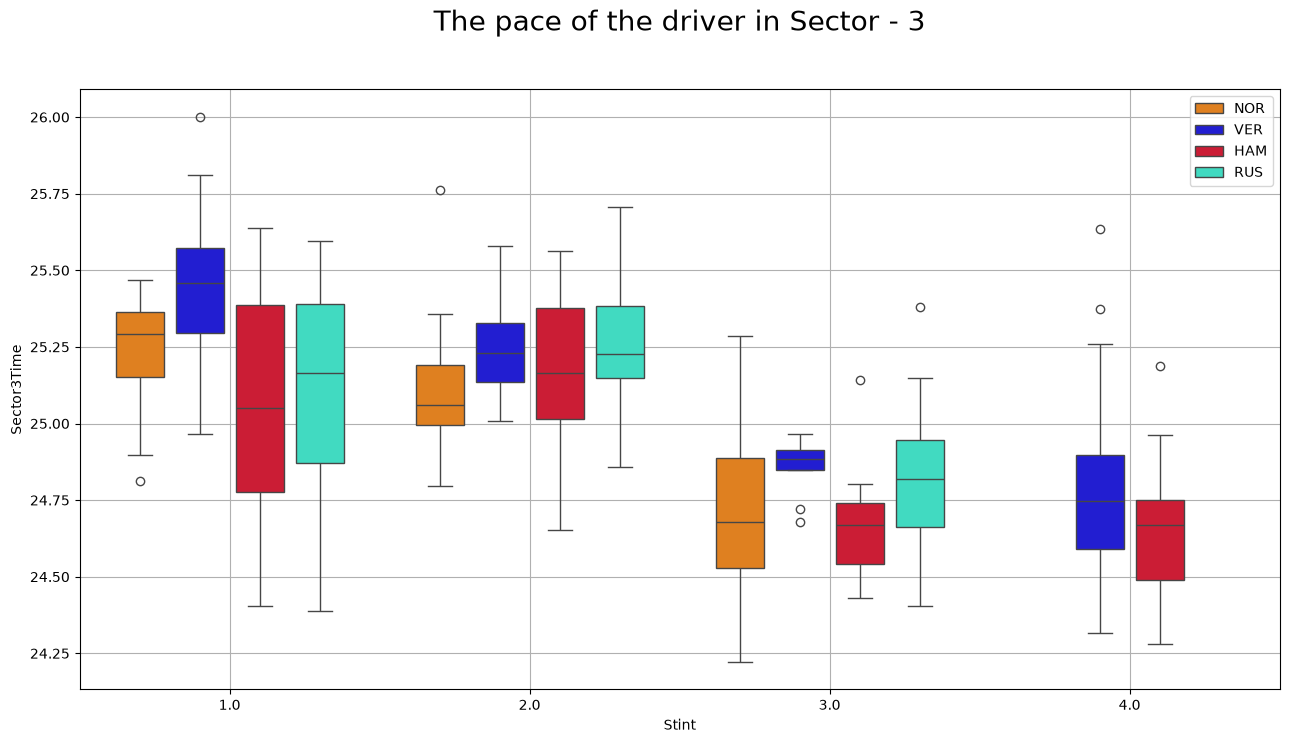

In [24]:
pace_grid = data_vis.create_pace_plot(
    laps_frame=filtered_race_laps_wo,
    x="Stint",
    y="Sector3Time",
    hue="Driver",
    figsize=(30, 10)
)

pace_grid.figure.suptitle(
    t="The pace of the driver in Sector - 3",
    fontsize=20
)
plt.subplots_adjust(left=0.3, right=0.7, top=0.9, bottom=0.3)
plt.show()

### KE Retention Plots

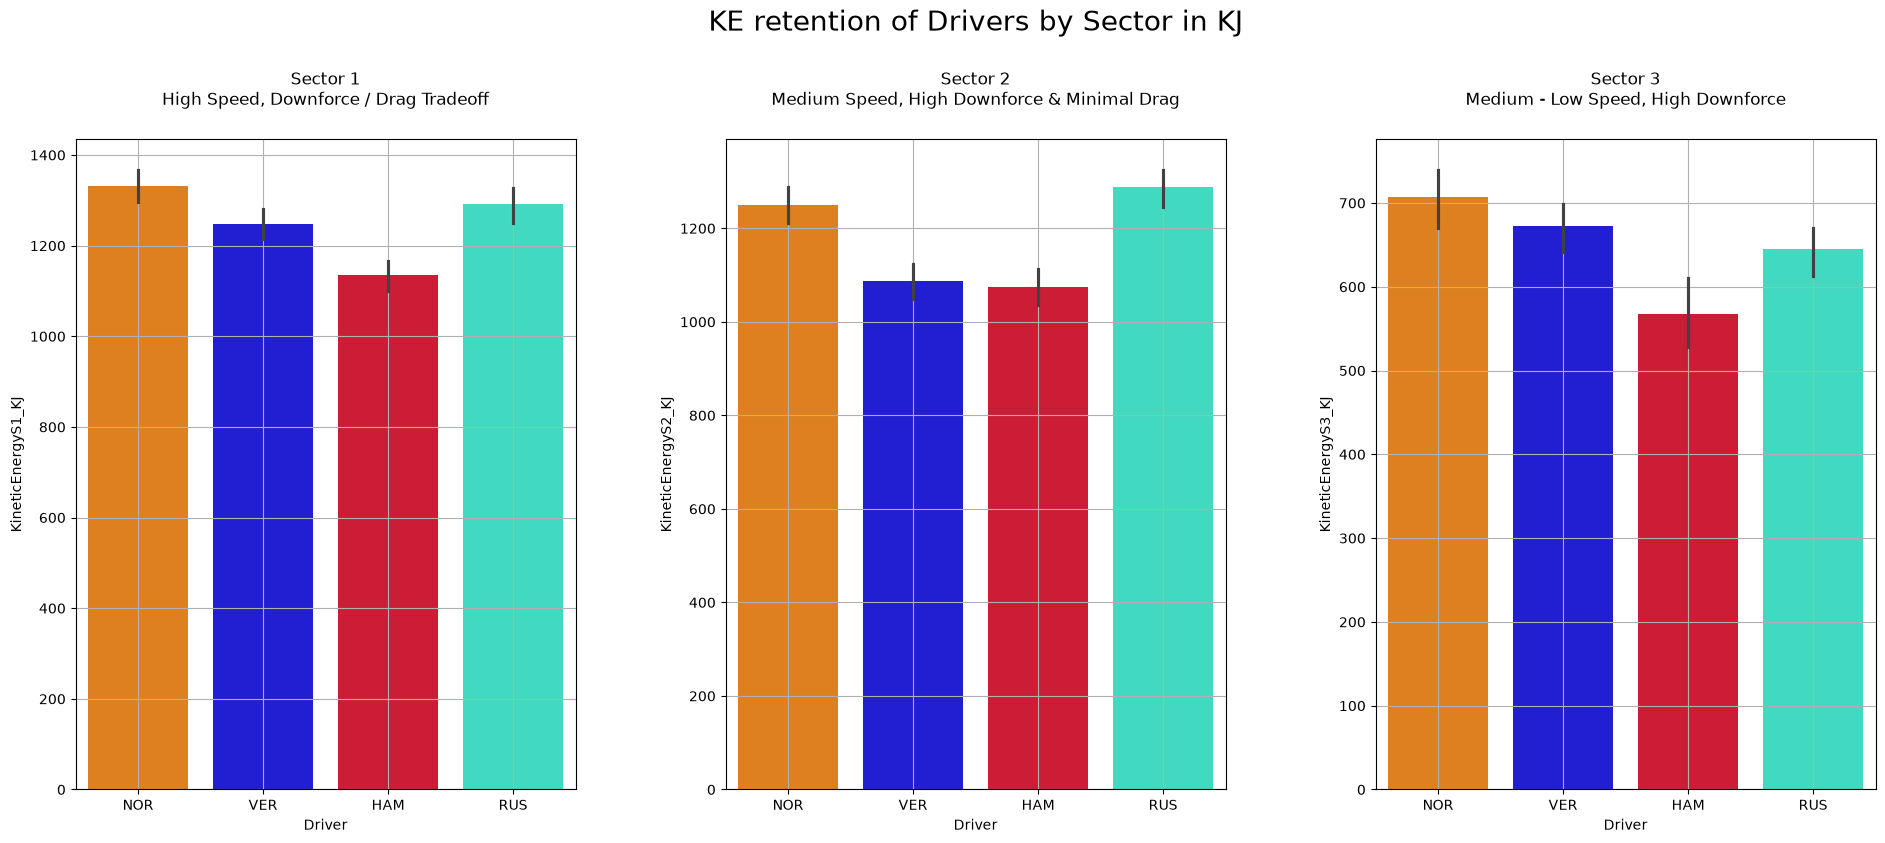

In [25]:
ke_grid = data_vis.create_bar_plots(
    nrows=1,
    ncols=3,
    figsize=(30, 10),
    data=filtered_race_laps_wo,
    hue="Driver",
    plot_kind="ke"
)

ke_grid.suptitle(
    t="KE retention of Drivers by Sector in KJ",
    fontsize=20
)
plt.subplots_adjust(
    left=0.2, right=0.8, bottom=0.2, top=0.85, wspace=0.3
)
plt.show()

### Power Deployment Plots

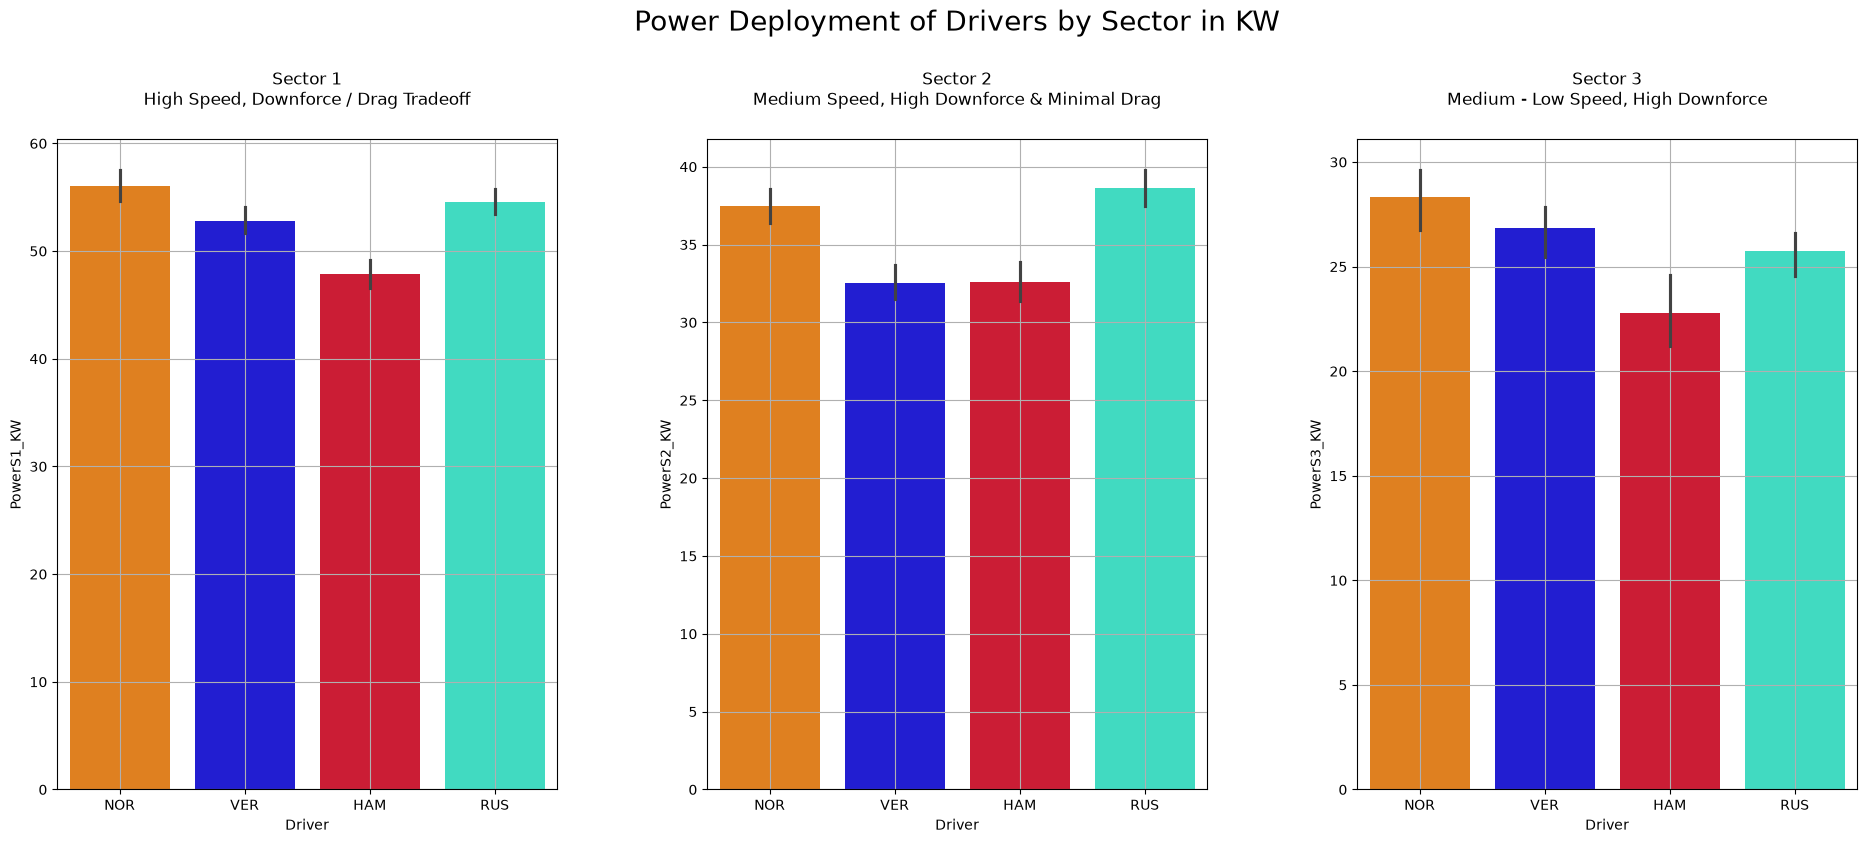

In [26]:
ke_grid = data_vis.create_bar_plots(
    nrows=1,
    ncols=3,
    figsize=(30, 10),
    data=filtered_race_laps_wo,
    hue="Driver",
    plot_kind="power"
)

ke_grid.suptitle(
    t="Power Deployment of Drivers by Sector in KW",
    fontsize=20
)
plt.subplots_adjust(
    left=0.2, right=0.8, bottom=0.2, top=0.85, wspace=0.3
)
plt.show()

### Quali Trim V Race Trim

In [27]:
# Generating all the features
race_performance = data_pipe.get_mean_race_laps(
    laps_frame=filtered_race_laps,
    drivers=top_4_drivers.to_list()
)

# ================ Aero Features ================
race_performance.loc[:, "FrontAEI"] = race_performance.apply(
    lambda x: data_pipe._calc_aero_efficiency(
        v_sector=x["SpeedI1"], 
        v_st=x["SpeedST"],
        sector_time=x["Sector1Time"],
        purple_sector_time=race_performance["Sector1Time"].min()
    ),
    axis=1
)
race_performance.loc[:, "BalancedAEI"] = race_performance.apply(
    lambda x: data_pipe._calc_aero_efficiency(
        v_sector=x["SpeedI2"], 
        v_st=x["SpeedST"],
        sector_time=x["Sector2Time"],
        purple_sector_time=race_performance["Sector2Time"].min()
    ),
    axis=1
)
race_performance.loc[:, "RearAEI"] = race_performance.apply(
    lambda x: data_pipe._calc_aero_efficiency(
        v_sector=x["SpeedFL"], 
        v_st=x["SpeedST"],
        sector_time=x["Sector3Time"],
        purple_sector_time=race_performance["Sector3Time"].min()
    ),
    axis=1
)

# ================ Kinetic Energy Features ================
race_performance.loc[:, "KineticEnergyS1_KJ"] = race_performance.apply(
    lambda x: data_pipe._calc_delta_kinetic_energy(
        v1=x["SpeedI1"], 
        v2=x["SpeedST"]
    ),
    axis=1
)
race_performance.loc[:, "KineticEnergyS2_KJ"] = race_performance.apply(
    lambda x: data_pipe._calc_delta_kinetic_energy(
        v1=x["SpeedI2"], 
        v2=x["SpeedST"]
    ),
    axis=1
)
race_performance.loc[:, "KineticEnergyS3_KJ"] = race_performance.apply(
    lambda x: data_pipe._calc_delta_kinetic_energy(
        v1=x["SpeedFL"], 
        v2=x["SpeedST"]
    ),
    axis=1
)

# ================ Power Features ================
race_performance["PowerS1_KW"] = (
    race_performance["KineticEnergyS1_KJ"] / 
    race_performance["Sector1Time"]
)
race_performance["PowerS2_KW"] = (
    race_performance["KineticEnergyS2_KJ"] / 
    race_performance["Sector2Time"]
)
race_performance["PowerS3_KW"] = (
    race_performance["KineticEnergyS3_KJ"] / 
    race_performance["Sector3Time"]
)

# ================ Auxiliary Features ================
# ERS Clipping
race_performance["ERS_Clipping"] = race_performance["SpeedST"] / race_performance["SpeedFL"]

# Acceleration Time
race_performance.loc[:, "AccelerationTime"] = race_performance.apply(
    lambda x: data_pipe.get_delta_acceleration_time(
        circuit="barcelona", 
        v1=x["SpeedFL"], 
        v2=x["SpeedST"]
    ),
    axis=1
)

race_performance

,Driver,Sector1Time,Sector2Time,Sector3Time,LapTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,FrontAEI,BalancedAEI,RearAEI,KineticEnergyS1_KJ,KineticEnergyS2_KJ,KineticEnergyS3_KJ,PowerS1_KW,PowerS2_KW,PowerS3_KW,ERS_Clipping,AccelerationTime
0,HAM,25.126108,33.606348,25.286303,84.062197,254.515152,260.909091,291.142857,316.212121,0.221999,0.229197,0.255756,1048.756736,950.601005,453.488715,41.739721,28.286352,17.934164,1.086106,5.216060
1,NOR,24.958231,33.881894,25.524288,84.421576,253.606061,259.651515,288.875000,323.954545,0.217372,0.220830,0.245389,1210.137209,1117.721323,640.288874,48.486498,32.988750,25.085475,1.121435,5.169464
2,RUS,24.948508,33.824591,25.544288,84.358576,253.045455,253.303030,291.468750,320.454545,0.219346,0.218153,0.250101,1151.421131,1147.536616,528.280418,46.151904,33.926105,20.680961,1.099447,5.177119
3,VER,25.052769,33.877409,25.685470,84.675788,257.666667,266.560606,293.698413,325.545455,0.218944,0.225628,0.246709,1179.079051,1040.213002,587.371832,47.063821,30.705211,22.867864,1.108435,5.115917


In [28]:
# Rescaling the Features
quali_performance_rescaled = data_pipe.get_rescaled_direct_features(
    laps_frame=quali_performance
)
quali_performance_rescaled = data_pipe.get_rescaled_inverse_features(
    laps_frame=quali_performance_rescaled
)

race_performance_rescaled = data_pipe.get_rescaled_direct_features(
    laps_frame=race_performance
)
race_performance_rescaled = data_pipe.get_rescaled_inverse_features(
    laps_frame=race_performance_rescaled
)

race_performance

,Driver,Sector1Time,Sector2Time,Sector3Time,LapTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,FrontAEI,BalancedAEI,RearAEI,KineticEnergyS1_KJ,KineticEnergyS2_KJ,KineticEnergyS3_KJ,PowerS1_KW,PowerS2_KW,PowerS3_KW,ERS_Clipping,AccelerationTime
0,HAM,0.000000,100.000000,100.000000,100.000000,31.803279,57.371429,47.017688,0.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,41.739721,28.286352,17.934164,100.000000,0.000000
1,NOR,94.525295,0.000000,40.379579,41.430229,12.131148,47.885714,0.000000,82.954545,0.000000,24.242933,0.000000,0.000000,15.139615,0.000000,48.486498,32.988750,25.085475,0.000000,46.529730
2,RUS,100.000000,20.796217,35.369140,51.697657,0.000000,0.000000,53.774167,45.454545,42.655426,0.000000,45.449155,36.383632,0.000000,59.961649,46.151904,33.926105,20.680961,62.237570,38.884785
3,VER,41.294179,1.627626,0.000000,0.000000,100.000000,100.000000,100.000000,100.000000,33.968064,67.687479,12.734877,19.245301,54.496804,28.328157,47.063821,30.705211,22.867864,36.798848,100.000000


In [29]:
polar_fig = data_vis.create_comparison_radar(
    quali_performance=quali_performance_rescaled,
    race_performance=race_performance_rescaled,
    drivers=top_4_drivers.to_list(),
    show_pace_categories=True,
    show_speed_categories=True,
    show_energy_categories=True,
)

polar_fig.show()


## Fin, Cheers!!